# Create Latlon Grid Geometry - Interactive Notebook

This notebook transforms an ECCO native (LLC90) grid geometry file to a latlon (0.5° regular) grid using the same mapping factors and transformation logic as the main EDP pipeline.

## Workflow

1. Load native grid geometry file
2. Load mapping factors
3. Calculate wet point indices from hFacC
4. Identify transformable variables
5. Transform variables to latlon grid
6. Calculate grid cell areas
7. Create output dataset
8. Apply metadata (optional)

## Setup and Imports

In [1]:
import sys
import datetime
import importlib.util
import logging
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

# Constants for area calculation
R_Earth = 6371.008800000000000000e3  # m
R_Earth_sq = R_Earth ** 2

# Set up logging
logging.basicConfig(
    format='%(levelname)-10s %(asctime)s %(message)s',
    level=logging.INFO)
log = logging.getLogger('create_latlon_grid_geometry')

print("✓ Imports complete")

✓ Imports complete


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [21]:
#importlib.reload(calc_depths_beneath_floating_ice_shelf)
%load_ext autoreload
%autoreload 2

from ice_shelf_cavity_geometry_helper import calc_depths_beneath_floating_ice_shelf

In [8]:
def unwrap_2d_lons(lons):
    """
    Removes 360-degree phase jumps from a 2D longitude array.
    Works on both standard and rotated grids (like MITgcm LLC90 faces).
    """
    # np.unwrap requires radians
    lon_rad = np.deg2rad(lons)
    
    # Unwrap along columns (axis 1) then rows (axis 0) 
    # to catch the dateline regardless of tile orientation
    lon_rad = np.unwrap(lon_rad, axis=1)
    lon_rad = np.unwrap(lon_rad, axis=0)
    
    return np.rad2deg(lon_rad)

## Load EDP Modules

We need to load the ECCOMappingFactors and ECCODatasetProductionConfig classes from the main EDP package.

In [2]:
# Create stub modules for dependencies we don't need
class StubAWS:
    """Stub AWS module since we only work with local files"""
    class utils:
        @staticmethod
        def is_s3_uri(path):
            return False
    
    class ecco_aws_s3_sync:
        @staticmethod
        def aws_s3_sync(*args, **kwargs):
            raise RuntimeError("AWS S3 not supported in this tool")

class StubECCOTask:
    """Stub ecco_task module since we don't use task objects"""
    pass

class StubPackage:
    """Minimal package stub"""
    aws = StubAWS()
    ecco_task = StubECCOTask()

# Register stub modules
sys.modules['ecco_dataset_production'] = StubPackage()
sys.modules['ecco_dataset_production.aws'] = StubAWS()
sys.modules['ecco_dataset_production.ecco_task'] = StubECCOTask()

# Load the real modules
src_dir = Path('../..') / 'src' / 'ecco_dataset_production'
mapping_factors_path = src_dir / 'ecco_mapping_factors.py'
configuration_path = src_dir / 'configuration.py'

def load_module_in_package(module_name, module_path, package_name):
    """Load a Python module as part of a package"""
    full_name = f"{package_name}.{module_name}"
    spec = importlib.util.spec_from_file_location(full_name, module_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[full_name] = module
    spec.loader.exec_module(module)
    return module

ecco_mapping_factors = load_module_in_package('ecco_mapping_factors', mapping_factors_path, 'ecco_dataset_production')
configuration = load_module_in_package('configuration', configuration_path, 'ecco_dataset_production')

ECCOMappingFactors = ecco_mapping_factors.ECCOMappingFactors
ECCODatasetProductionConfig = configuration.ECCODatasetProductionConfig

print("✓ EDP modules loaded successfully")

✓ EDP modules loaded successfully


## Configuration

Set the paths to your input files:

In [387]:
# ===== EDIT THESE PATHS =====
#native_grid_file = '/path/to/GRID_GEOMETRY_ECCO_V4r6_native_llc0090.nc'
native_grid_file = '/Users/ifenty/tmp/GRID_GEOMETRY_ECCO_V4r6_native_llc0090.nc'
#mapping_factors_loc = '/path/to/mapping_factors'
#mapping_factors_loc = '/Users/ifenty/tmp/mapping_factors_method_2'
mapping_factors_loc = '/Users/ifenty/Library/CloudStorage/Box-Box/ifenty/Projects/ECCO/ECCOv4/R6/mapping_factors'
output_file = '/Users/ifenty/tmp/pre_GRID_GEOMETRY_ECCO_V4r6_latlon_0p50deg.nc'
#ecco_cfg_file = '../../configs/config_V4r6.yaml'
ecco_cfg_file = '/Users/ifenty/git_repo_others/ECCO-Dataset-Production/configs/config_V4r6.yaml'
# ============================

print(f"Native grid file: {native_grid_file}")
print(f"Mapping factors: {mapping_factors_loc}")
print(f"Output file: {output_file}")
print(f"Config file: {ecco_cfg_file}")

Native grid file: /Users/ifenty/tmp/GRID_GEOMETRY_ECCO_V4r6_native_llc0090.nc
Mapping factors: /Users/ifenty/Library/CloudStorage/Box-Box/ifenty/Projects/ECCO/ECCOv4/R6/mapping_factors
Output file: /Users/ifenty/tmp/pre_GRID_GEOMETRY_ECCO_V4r6_latlon_0p50deg.nc
Config file: /Users/ifenty/git_repo_others/ECCO-Dataset-Production/configs/config_V4r6.yaml


In [162]:
latlon_area_and_radius = xr.open_dataset(Path(mapping_factors_loc) / 'latlon_grid_area_and_radius.nc')

## Step 1: Load Configuration

In [40]:
log.info(f"Loading configuration from {ecco_cfg_file}")
cfg = ECCODatasetProductionConfig(cfgfile=ecco_cfg_file)

print(f"\n✓ Configuration loaded")
print(f"  ECCO version: {cfg['ecco_version']}")
print(f"  Product version: {cfg['product_version']}")
print(f"  Latlon resolution: {cfg['latlon_grid_resolution']}°")
print(f"  Native grid label: {cfg['ecco_production_filestr_grid_label']['native']}")
print(f"  Latlon grid label: {cfg['ecco_production_filestr_grid_label']['latlon']}")

INFO       2026-05-25 18:29:14,818 Loading configuration from /Users/ifenty/git_repo_others/ECCO-Dataset-Production/configs/config_V4r6.yaml



✓ Configuration loaded
  ECCO version: V4r6
  Product version: Version 4, Release 6
  Latlon resolution: 0.5°
  Native grid label: llc0090
  Latlon grid label: 0p50deg


## Step 2: Load Native Grid File

In [41]:
log.info(f"Loading native grid file: {native_grid_file}")
native_ds = xr.open_dataset(native_grid_file)

print(f"\n✓ Native grid loaded")
print(f"  Variables: {len(native_ds.data_vars)}")
print(f"  Dimensions: {dict(native_ds.dims)}")
print(f"\n  Data variables:")
for var in sorted(native_ds.data_vars):
    print(f"    {var:20s} {str(native_ds[var].dims):40s} {native_ds[var].shape}")

INFO       2026-05-25 18:29:19,859 Loading native grid file: /Users/ifenty/tmp/GRID_GEOMETRY_ECCO_V4r6_native_llc0090.nc



✓ Native grid loaded
  Variables: 39
  Dimensions: {'i': 90, 'i_g': 90, 'j': 90, 'j_g': 90, 'k': 50, 'k_u': 50, 'k_l': 50, 'k_p1': 51, 'tile': 13, 'nb': 4, 'nv': 2, 'j_gg': 91, 'i_gg': 91}

  Data variables:
    CS                   ('tile', 'j', 'i')                       (13, 90, 90)
    Depth                ('tile', 'j', 'i')                       (13, 90, 90)
    K_icefront           ('tile', 'j', 'i')                       (13, 90, 90)
    PHrefC               ('k',)                                   (50,)
    PHrefF               ('k_p1',)                                (51,)
    R_icefront           ('tile', 'j', 'i')                       (13, 90, 90)
    SN                   ('tile', 'j', 'i')                       (13, 90, 90)
    drC                  ('k_p1',)                                (51,)
    drF                  ('k',)                                   (50,)
    dxC                  ('tile', 'j', 'i_g')                     (13, 90, 90)
    dxF                  ('ti

/var/folders/1_/d2mlmphx1y73x199m02l7_qc0000gq/T/ipykernel_68980/2543546182.py:6: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Dimensions: {dict(native_ds.dims)}")


## Step 3: Verify hFacC and Calculate Wet Points

The hFacC variable is required to identify wet (ocean) vs dry (land) points at each depth level.

In [6]:
if 'hFacC' not in native_ds:
    raise RuntimeError(
        f"Native grid file must contain 'hFacC' variable for wet point calculation.\n"
        f"File: {native_grid_file}\n"
        f"Variables found: {list(native_ds.data_vars)}")

print("✓ Found hFacC variable")
print(f"  Shape: {native_ds['hFacC'].shape}")
print(f"  Dims: {native_ds['hFacC'].dims}")

# Calculate wet point indices
log.info("Calculating wet point indices from hFacC...")
hFacC = native_ds['hFacC']
native_wet_indices = {}

for z in range(hFacC.shape[0]):
    native_wet_indices[z] = np.where(hFacC[z, :] > 0)

print(f"\n✓ Wet point indices calculated for {len(native_wet_indices)} depth levels")
print(f"\nExample - Surface (z=0):")
print(f"  Number of wet points: {len(native_wet_indices[0][0])}")
print(f"  Total native grid points: {hFacC[0, :].size}")
print(f"  Wet fraction: {len(native_wet_indices[0][0]) / hFacC[0, :].size * 100:.1f}%")

INFO       2026-05-25 18:13:33,970 Calculating wet point indices from hFacC...


✓ Found hFacC variable
  Shape: (50, 13, 90, 90)
  Dims: ('k', 'tile', 'j', 'i')

✓ Wet point indices calculated for 50 depth levels

Example - Surface (z=0):
  Number of wet points: 60570
  Total native grid points: 105300
  Wet fraction: 57.5%


### Visualize "Depth" field

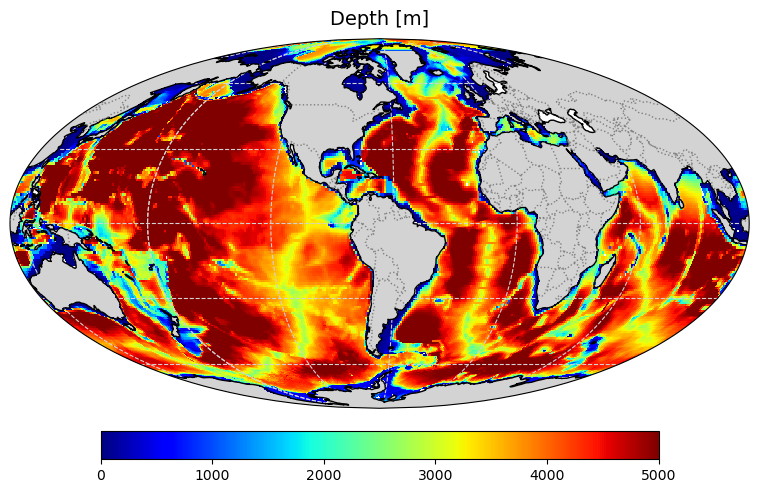

In [46]:
fig = plt.figure(figsize=(12, 6))

# Choose your global map projection here (e.g., Mollweide, Robinson, Orthographic)
map_projection = ccrs.Mollweide(central_longitude=-67)
ax = plt.axes(projection=map_projection)

# Make the map global and add features
ax.set_global()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black', zorder=3)
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray', zorder=3)
ax.gridlines(draw_labels=False, linestyle='--', color='lightgray')
ax.add_feature(cfeature.LAND, linestyle='-', color='lightgray', edgecolor='gray', zorder=1)

ax.set_facecolor('white')

# Plot using pcolormesh. 
# CRITICAL: transform must be PlateCarree because our input coordinates are Lat/Lon degrees.

vmin=0
vmax=500

# set to nan all depths that are masked out 
D = np.where(native_ds.maskC_wet_in_column == True, native_ds.Depth, np.nan)

# 2. Set NaN values ('bad' data) to none (transparent)
cmap = plt.colormaps['jet'].copy()
cmap.set_bad(color='none')
vmax=5000

for tile in range(13):

    fixed_lons = unwrap_2d_lons(native_ds.XGG[tile])
    
    im = ax.pcolormesh(fixed_lons, native_ds.YGG[tile], D[tile],
                       transform=ccrs.PlateCarree(),
                       cmap=cmap, 
                       vmin=vmin, 
                       vmax=vmax, 
                       edgecolors='none', # Change to 'white' if you want to see tile borders
                       antialiased=False)

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
#cbar.set_label('Depth [m]')
plt.title("Depth [m]", fontsize=14, pad=10)
plt.show()

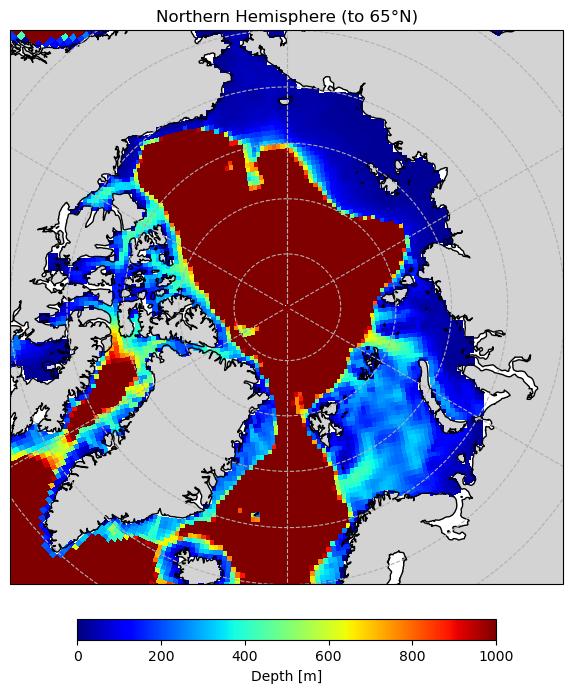

In [10]:
fig = plt.figure(figsize=(9,9))

# 1. Define the North Polar Stereographic projection
# Change central_longitude to rotate the map (e.g., -90 for North America up)
projection_n = ccrs.NorthPolarStereo(central_longitude=0)
ax = plt.axes(projection=projection_n)

# 2. Limit the map strictly from 65°N to 90°N
ax.set_extent([-180, 180, 65, 90], crs=ccrs.PlateCarree())

# 3. Force the map boundary to be a neat circle at 65°N
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T

# Add map features
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=False, linestyle='--')
vmax=1000

for tile in range(13):

    fixed_lons = unwrap_2d_lons(native_ds.XGG[tile])
    
    im = ax.pcolormesh(fixed_lons, native_ds.YGG[tile], D[tile],
                       transform=ccrs.PlateCarree(),
                       cmap=cmap, 
                       vmin=vmin, 
                       vmax=vmax, 
                       edgecolors='none', # Change to 'white' if you want to see tile borders
                       antialiased=False)

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
cbar.set_label('Depth [m]')

plt.title("Northern Hemisphere (to 65°N)")
plt.show()

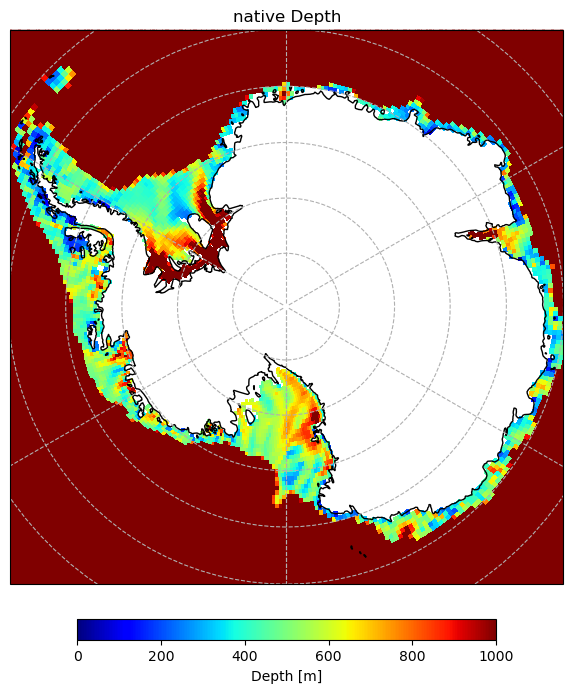

In [96]:
fig = plt.figure(figsize=(9,9))

# 1. Define the North Polar Stereographic projection
# Change central_longitude to rotate the map (e.g., -90 for North America up)
projection_n = ccrs.SouthPolarStereo(central_longitude=0)
ax = plt.axes(projection=projection_n)

# 2. Limit the map strictly from 65°N to 90°N
ax.set_extent([-180, 180, -90, -65], crs=ccrs.PlateCarree())

# 3. Force the map boundary to be a neat circle at 65°N
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T

# Add map features
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
#ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=False, linestyle='--')

vmin=0
vmax=1000
for tile in range(13):

    fixed_lons = unwrap_2d_lons(native_ds.XGG[tile])
    
    im = ax.pcolormesh(fixed_lons, native_ds.YGG[tile], D[tile],
                       transform=ccrs.PlateCarree(),
                       cmap=cmap, 
                       vmin=vmin, 
                       vmax=vmax, 
                       edgecolors='none', # Change to 'white' if you want to see tile borders
                       antialiased=False)

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
cbar.set_label('Depth [m]')

plt.title("native Depth")
plt.show()

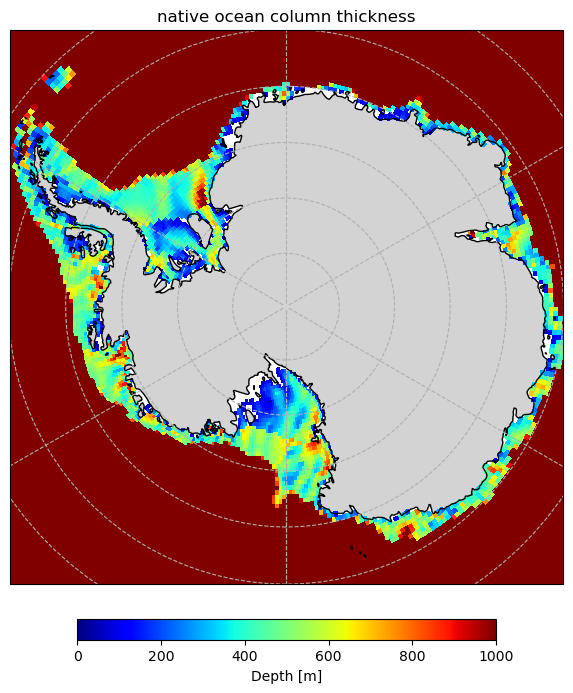

In [83]:
fig = plt.figure(figsize=(9,9))

# 1. Define the North Polar Stereographic projection
# Change central_longitude to rotate the map (e.g., -90 for North America up)
projection_n = ccrs.SouthPolarStereo(central_longitude=0)
ax = plt.axes(projection=projection_n)

# 2. Limit the map strictly from 65°N to 90°N
ax.set_extent([-180, 180, -90, -65], crs=ccrs.PlateCarree())

# 3. Force the map boundary to be a neat circle at 65°N
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T

# Add map features
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=False, linestyle='--')

vmin=0
vmax=1000
for tile in range(13):

    tmp = native_ds.ocean_column_thickness[tile] + 0
    tmp = np.where(tmp ==0, np.nan, tmp)
    fixed_lons = unwrap_2d_lons(native_ds.XGG[tile])
    
    im = ax.pcolormesh(fixed_lons, native_ds.YGG[tile], tmp,
                       transform=ccrs.PlateCarree(),
                       cmap=cmap, 
                       vmin=vmin, 
                       vmax=vmax, 
                       edgecolors='none', # Change to 'white' if you want to see tile borders
                       antialiased=False)

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
cbar.set_label('Depth [m]')

plt.title("native ocean column thickness")
plt.show()

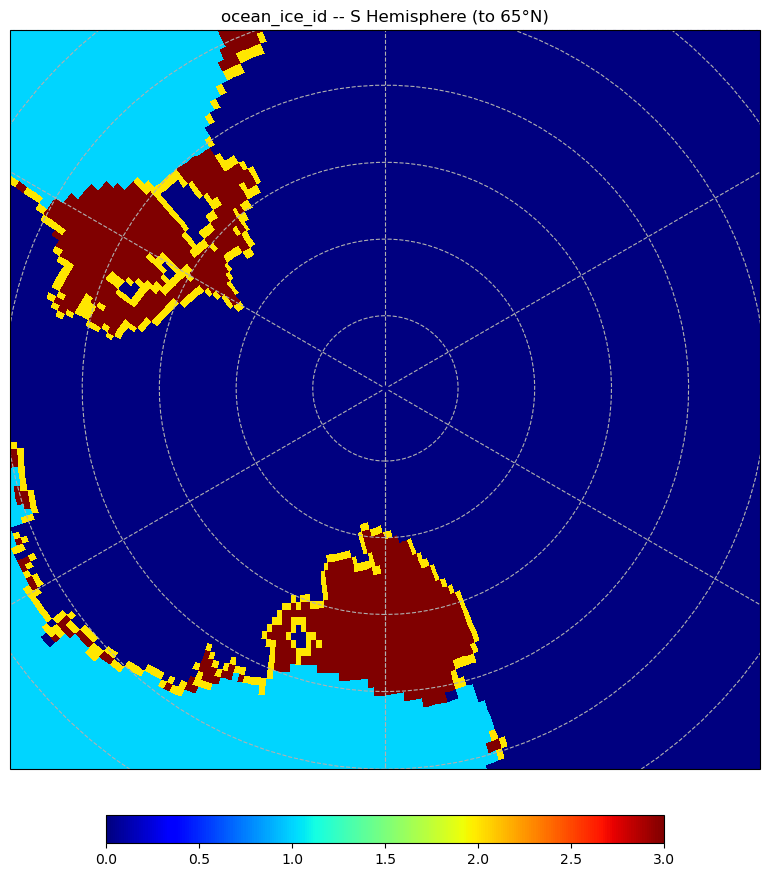

In [57]:
fig = plt.figure(figsize=(12,12))

# 1. Define the North Polar Stereographic projection
# Change central_longitude to rotate the map (e.g., -90 for North America up)
projection_n = ccrs.SouthPolarStereo(central_longitude=0)
ax = plt.axes(projection=projection_n)

# 2. Limit the map strictly from 65°N to 90°N
ax.set_extent([-180, 180, -90, -75], crs=ccrs.PlateCarree())

# 3. Force the map boundary to be a neat circle at 65°N
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T

# Add map features
#ax.add_feature(cfeature.COASTLINE, edgecolor='black')
#ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=False, linestyle='--')

vmin=0
vmax=3
for tile in range(13):

    fixed_lons = unwrap_2d_lons(native_ds.XGG[tile])
    
    im = ax.pcolormesh(fixed_lons, native_ds.YGG[tile], native_ds.ocean_ice_id[tile],
                       transform=ccrs.PlateCarree(),
                       cmap=cmap, 
                       vmin=vmin, 
                       vmax=vmax, 
                       edgecolors='none', # Change to 'white' if you want to see tile borders
                       antialiased=False)

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
#cbar.set_label('Depth [m]')

plt.title("ocean_ice_id -- S Hemisphere (to 65°N)")
plt.show()

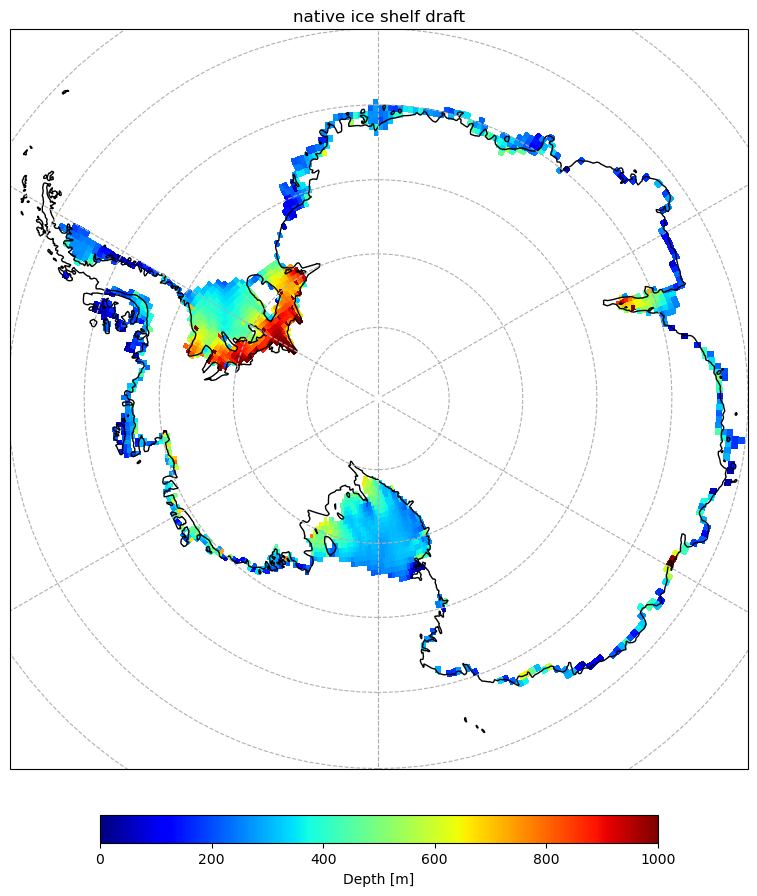

In [94]:
fig = plt.figure(figsize=(12,12))

# 1. Define the North Polar Stereographic projection
# Change central_longitude to rotate the map (e.g., -90 for North America up)
projection_n = ccrs.SouthPolarStereo(central_longitude=0)
ax = plt.axes(projection=projection_n)

# 2. Limit the map strictly from 65°N to 90°N
ax.set_extent([-180, 180, -90, -65], crs=ccrs.PlateCarree())

# 3. Force the map boundary to be a neat circle at 65°N
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T

# Add map features
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
#ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=False, linestyle='--')

vmin=0
vmax=1000
for tile in range(13):

    fixed_lons = unwrap_2d_lons(native_ds.XGG[tile])
    tmp = np.where(native_ds.ice_shelf_draft[tile] ==0, np.nan, native_ds.ice_shelf_draft[tile])
    im = ax.pcolormesh(fixed_lons, native_ds.YGG[tile], tmp,
                       transform=ccrs.PlateCarree(),
                       cmap=cmap, 
                       vmin=vmin, 
                       vmax=vmax, 
                       edgecolors='none', # Change to 'white' if you want to see tile borders
                       antialiased=False)

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
cbar.set_label('Depth [m]')

plt.title("native ice shelf draft")
plt.show()

## Step 4: Load Mapping Factors

In [14]:
log.info(f"Loading mapping factors from: {mapping_factors_loc}")
mapping_factors = ECCOMappingFactors(mapping_factors_loc=mapping_factors_loc)

print("\n✓ Mapping factors loaded")
print(f"  Latlon grid shape: {mapping_factors.latlon_shape}")
print(f"  Number of latitudes: {len(mapping_factors.lats_1D)}")
print(f"  Number of longitudes: {len(mapping_factors.lons_1D)}")
print(f"  Latitude range: [{mapping_factors.lats_1D.min():.1f}, {mapping_factors.lats_1D.max():.1f}]")
print(f"  Longitude range: [{mapping_factors.lons_1D.min():.1f}, {mapping_factors.lons_1D.max():.1f}]")

# Check sparse matrix for surface level
sparse_matrix_0 = mapping_factors.native_to_latlon_mapping_factors(level=0)
print(f"\n  Sparse matrix (surface):")
print(f"    Shape: {sparse_matrix_0.shape}")
print(f"    Non-zero elements: {sparse_matrix_0.nnz}")
print(f"    Density: {sparse_matrix_0.nnz / (sparse_matrix_0.shape[0] * sparse_matrix_0.shape[1]) * 100:.3f}%")

INFO       2026-05-25 18:13:39,502 Loading mapping factors from: /Users/ifenty/Library/CloudStorage/Box-Box/ifenty/Projects/ECCO/ECCOv4/R6/mapping_factors



✓ Mapping factors loaded
  Latlon grid shape: (360, 720)
  Number of latitudes: 360
  Number of longitudes: 720
  Latitude range: [-89.8, 89.8]
  Longitude range: [-179.8, 179.8]

  Sparse matrix (surface):
    Shape: (60570, 259200)
    Non-zero elements: 238528
    Density: 0.002%


In [171]:
latitude_bnds = mapping_factors.latitude_bounds
longitude_bnds = mapping_factors.longitude_bounds
depth_bnds = mapping_factors.depth_bounds
lats_1D = mapping_factors.lats_1D
lons_1D = mapping_factors.lons_1D

In [15]:
sparse_matrix_aw = mapping_factors.native_to_latlon_mapping_factors(level='any_wet_in_column.xz')

## Transform Variables to Latlon Grid


In [175]:
native_wet_indices.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [280]:
def transform_variable_to_latlon(native_ds, var_name, native_wet_indices,
                                  mapping_factors, field_type='3D', apply_land_mask = True):
    
    """Transform a single variable from native to latlon grid."""
    log.info(f"Transforming {var_name} {field_type}")
    
    native_var = native_ds[var_name]
    latitude = mapping_factors.lats_1D
    longitude = mapping_factors.lons_1D
    nlat, nlon = mapping_factors.latlon_shape
    
    if field_type == '3D':
        # Get depth dimension
        depth_dim = None
        for dim in native_var.dims:
            if dim in ['k', 'k_u', 'k_l', 'k_p1']:
                depth_dim = dim
                break
        
        if depth_dim is None:
            raise ValueError(f"Could not find depth dimension in 3D variable {var_name}")
        
        nz = native_var.sizes[depth_dim]
        variable_as_latlon = np.zeros((nz, nlat, nlon))
        var = native_var.values.squeeze()
        
        for z in range(nz):
            var_z = var[z, :]
            wet_pts = native_wet_indices[z]
            var_z_wet = var_z[wet_pts]
            var_z_latlon = mapping_factors.native_to_latlon_mapping_factors(level=z).T.dot(var_z_wet)

            # sometimes we don't want to nan out the land points
            if apply_land_mask:
                var_z_latlon_land_masked = np.where(
                    np.isnan(mapping_factors.latlon_land_mask(level=z)),
                    np.nan,
                    var_z_latlon)
                variable_as_latlon[z, :, :] = var_z_latlon_land_masked.reshape(nlat, nlon)
            else:
                variable_as_latlon[z, :, :] = var_z_latlon.reshape(nlat, nlon)
        
        latlon_var = xr.DataArray(
            variable_as_latlon,
            dims=[depth_dim, 'latitude', 'longitude'],
            coords={
                depth_dim: native_ds[depth_dim],
                'latitude': latitude,
                'longitude': longitude
            },
            name=var_name
        )
    elif field_type == '2D':
        # 2D variable
        variable_as_latlon = np.zeros((nlat, nlon))
        var = native_var.values.squeeze()
        wet_pts = native_wet_indices[0]
        var_wet = var[wet_pts]
        var_latlon = mapping_factors.native_to_latlon_mapping_factors(level=0).T.dot(var_wet)
        
        
        if apply_mask:
            var_latlon_land_masked = np.where(
                np.isnan(mapping_factors.latlon_land_mask(level=0)),
                np.nan,
                var_latlon)
            variable_as_latlon[:, :] = var_latlon_land_masked.reshape(nlat, nlon)
        else:
            variable_as_latlon[:, :] = var_latlon.reshape(nlat, nlon)
            
        latlon_var = xr.DataArray(
            variable_as_latlon,
            dims=['latitude', 'longitude'],
            coords={
                'latitude': latitude,
                'longitude': longitude
            },
            name=var_name
        )
    elif field_type == '2D_any_wet_in_k':
        # 2D variable
        variable_as_latlon = np.zeros((nlat, nlon))
        var = native_var.values.squeeze()
        
        wet_pts = native_wet_indices
        
        var_wet = var[wet_pts]
        var_latlon = mapping_factors.native_to_latlon_mapping_factors(level='any_wet_in_column.xz').T.dot(var_wet)

        if apply_mask:
            var_latlon_land_masked = np.where(
                np.isnan(mapping_factors.latlon_land_mask(level=0)),
                np.nan,
                var_latlon)
            variable_as_latlon[:, :] = var_latlon_land_masked.reshape(nlat, nlon)
        else:
            variable_as_latlon[:, :] = var_latlon.reshape(nlat, nlon)
            
        latlon_var = xr.DataArray(
            variable_as_latlon,
            dims=['latitude', 'longitude'],
            coords={
                'latitude': latitude,
                'longitude': longitude
            },
            name=var_name
        )
    
    latlon_var.attrs = native_var.attrs.copy()
    return latlon_var

print("✓ Transformation function defined")

✓ Transformation function defined


### Transform hFacC (3D - grid cell fraction)

In [300]:
print("Transforming hFacC (grid cell fraction)...")
hFacC_latlon = transform_variable_to_latlon(
    native_ds, 'hFacC', native_wet_indices,
    mapping_factors, field_type='3D', apply_land_mask=False)

print(f"\n✓ hFacC transformed")
print(f"  Native shape: {native_ds['hFacC'].shape}")
print(f"  Latlon shape: {hFacC_latlon.shape}")
print(f"  Value range: [{np.nanmin(hFacC_latlon.values):.2f}, {np.nanmax(hFacC_latlon.values):.2f}]")


INFO       2026-05-25 21:05:44,719 Transforming hFacC 3D


Transforming hFacC (grid cell fraction)...

✓ hFacC transformed
  Native shape: (50, 13, 90, 90)
  Latlon shape: (50, 360, 720)
  Value range: [0.00, 1.00]


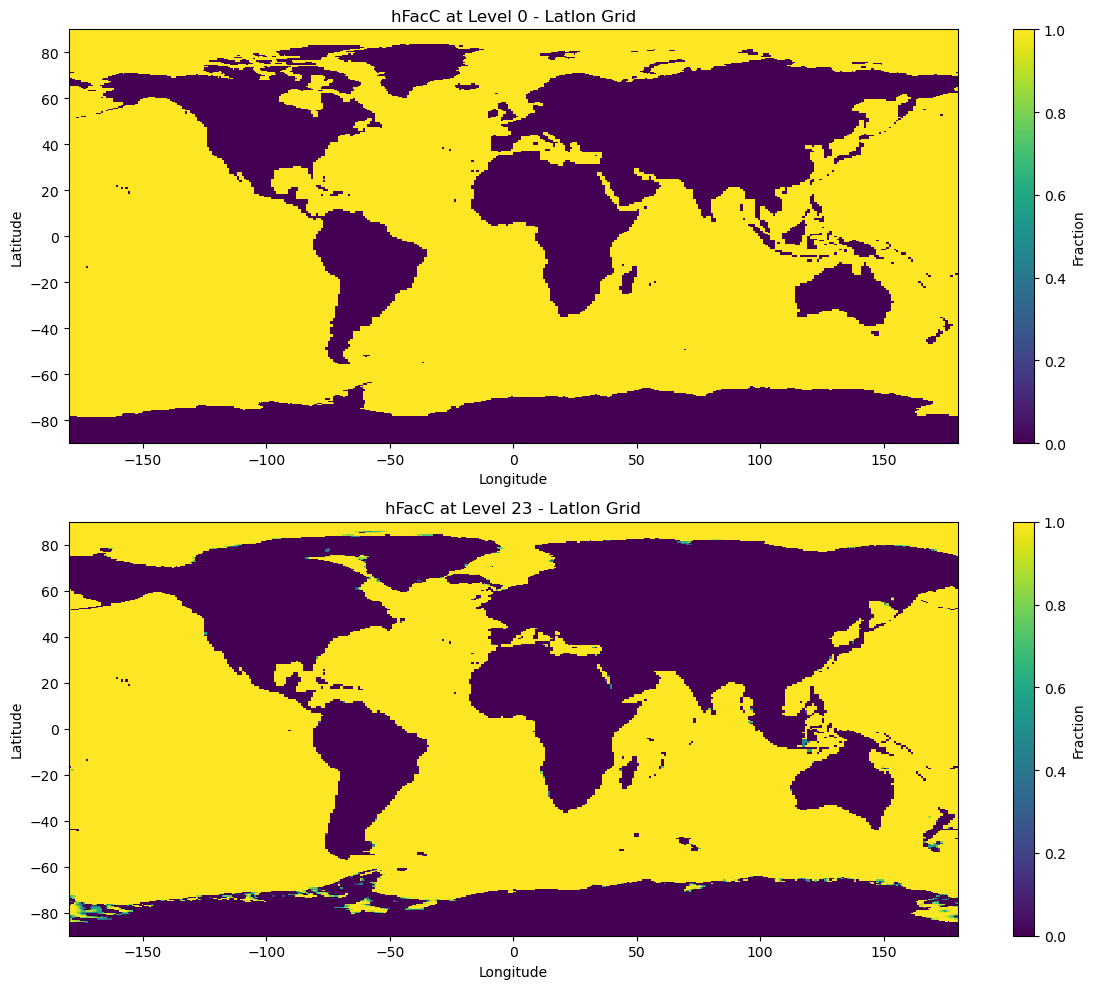

In [301]:
# Visualize surface and depth level 20
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for i, z in enumerate([0, 23]):
    im = axes[i].pcolormesh(hFacC_latlon.longitude, hFacC_latlon.latitude, 
                            hFacC_latlon[z, :, :], 
                            cmap='viridis', vmin=0, vmax=1, shading='auto')
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'hFacC at Level {z} - Latlon Grid')
    plt.colorbar(im, ax=axes[i], label='Fraction')

plt.tight_layout()
plt.show()

# sanity check

In [302]:
land_ins_k0_from_latlon_mask = mapping_factors.latlon_land_mask(0)

In [303]:
np.where(hFacC_latlon[0].values.ravel()>0)

(array([ 16567,  16568,  16569, ..., 259197, 259198, 259199]),)

In [304]:
np.where(land_ins_k0_from_latlon_mask==1)

(array([ 16567,  16568,  16569, ..., 259197, 259198, 259199]),)

# Create ocean column thickness

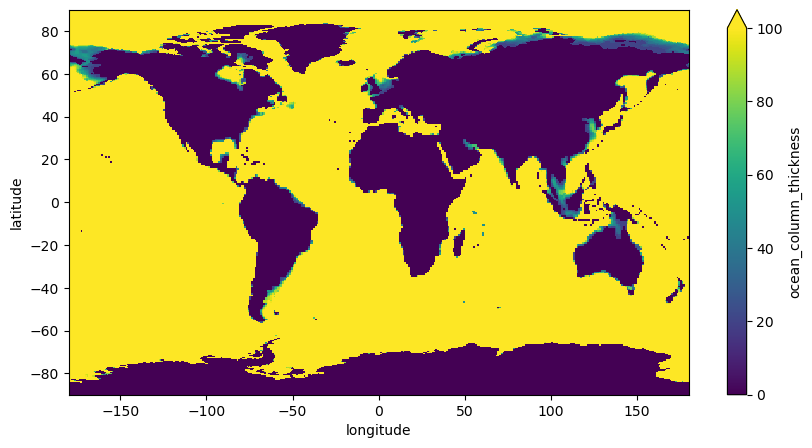

In [307]:
ocean_column_thickness_latlon = (hFacC_latlon * native_ds.drF).sum(dim='k')
ocean_column_thickness_latlon.name = 'ocean_column_thickness'

# create a first-pass Depth field by copying ocean column thickness
# we need to fix beneath the floating ice shelves, ofc
Depth_latlon = ocean_column_thickness_latlon.copy(deep=True)
Depth_latlon.name = 'Depth'

plt.figure(figsize=(10,5))
ocean_column_thickness_latlon.plot(vmin=0,vmax=100)


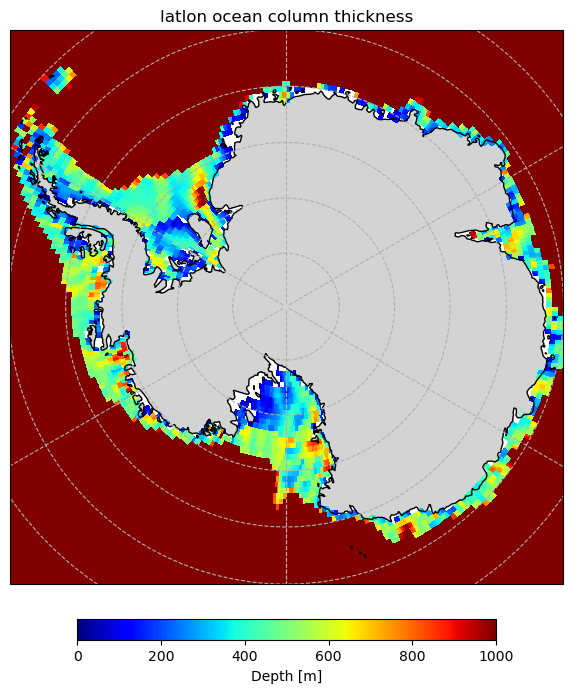

In [308]:
fig = plt.figure(figsize=(9,9))

# 1. Define the North Polar Stereographic projection
# Change central_longitude to rotate the map (e.g., -90 for North America up)
projection_n = ccrs.SouthPolarStereo(central_longitude=0)
ax = plt.axes(projection=projection_n)

# 2. Limit the map strictly from 65°N to 90°N
ax.set_extent([-180, 180, -90, -65], crs=ccrs.PlateCarree())

# 3. Force the map boundary to be a neat circle at 65°N
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T

# Add map features
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=False, linestyle='--')

vmin=0
vmax=1000
# 2. Set NaN values ('bad' data) to none (transparent)
cmap = plt.colormaps['jet'].copy()
cmap.set_bad(color='none')

Depth_latlon.values = np.where(Depth_latlon == 0, np.nan, Depth_latlon)

tmp = np.where(ocean_column_thickness_latlon ==0, np.nan, ocean_column_thickness_latlon)
im = ax.pcolormesh(ocean_column_thickness_latlon.longitude, ocean_column_thickness_latlon.latitude,
                   tmp,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap, 
                   vmin=vmin, 
                   vmax=vmax, 
                   edgecolors='none', # Change to 'white' if you want to see tile borders
                   antialiased=False)

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
cbar.set_label('Depth [m]')

plt.title("latlon ocean column thickness")
plt.show()

# Create cavity mask

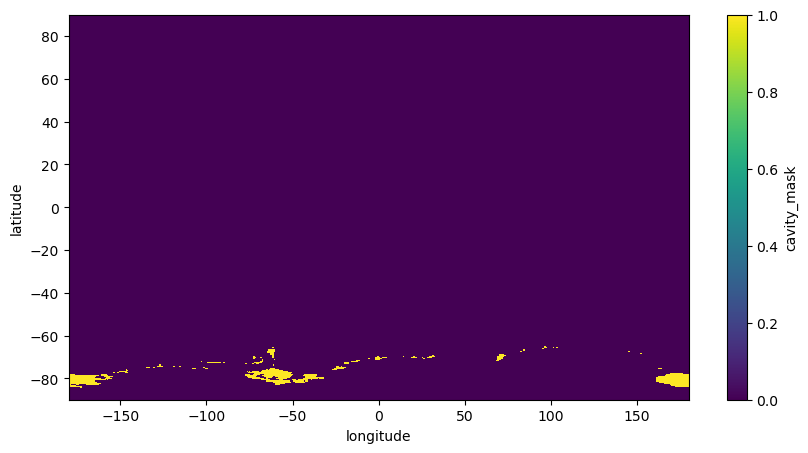

In [309]:
# wet anywhere in the column
wet_in_k = np.where(ocean_column_thickness_latlon>0, 1, 0)

# wet at the surface
dry_at_k0 = np.where(hFacC_latlon[0]==0, 1, 0)

# an ice shelf cavity is where we are both
# ... dry at the surface AND
# ... wet at depth

cavity_mask_latlon = ocean_column_thickness_latlon.copy(deep=True);
cavity_mask_latlon.values = np.where(np.logical_and(dry_at_k0, wet_in_k), 1, 0)
cavity_mask_latlon.name = 'cavity_mask'

plt.figure(figsize=(10,5))
cavity_mask_latlon.plot()

In [349]:
tmp_2D_DA = ocean_column_thickness_latlon.copy(deep=True)
tmp_2D_DA.values[:] = 0.0
tmp_2D_DA.name = ''

In [350]:
(hFacC_latlon[:, a[i],b[i]]*native_ds.drF).sum()

<xarray.DataArray ()> Size: 8B
array(22463.67869334)
Coordinates:
    latitude   float64 8B -65.25
    longitude  float64 8B 96.75

In [351]:
#THIS IS OK now

ice_shelf_draft_latlon = tmp_2D_DA.copy(deep=True)
ice_shelf_draft_latlon.name = 'ice_shelf_draft'

oct_tmp_latlon = tmp_2D_DA.copy(deep=True)
oct_tmp_latlon.name = 'oct_tmp_latlon'

new_depth_latlon = tmp_2D_DA.copy(deep=True)
new_depth_latlon.name = 'new_depth'
new_depth_latlon.values = Depth_latlon.values + 0

seafloor_depth_beneath_ice_shelf = tmp_2D_DA.copy(deep=True)
ice_shelf_m_tmp = tmp_2D_DA.copy(deep=True)

cm_ins =  np.where(cavity_mask_latlon > 0)
a,b = cm_ins

for i in range(len(a)):
    ai = a[i]
    bi = b[i]
    ice_shelf_m_tmp[ai,bi] = 1
    oct_tmp_latlon.values[ai, bi] = (hFacC_latlon[:, ai, bi]*native_ds.drF).sum()
    tmp = hFacC_latlon[:, ai, bi].copy(deep=True)
    tmp.values = np.where(np.isnan(tmp), 0, tmp)
    hFacC_here = tmp
    ocean_column_thickness_here = ocean_column_thickness_latlon[ai, bi]
    
    X = calc_depths_beneath_floating_ice_shelf(hFacC_here, ocean_column_thickness_here, native_ds.drF, debug=True)
    ice_shelf_draft_latlon.values[ai,bi] = X[0]
    seafloor_depth_beneath_ice_shelf.values[ai,bi] = X[1]
    new_depth_latlon.values[ai,bi] = seafloor_depth_beneath_ice_shelf.values[ai,bi]

nonzero hFacCs #=2, [23 24]
[0.3508829 0.9202303]
ice_shelf_tmp : [1.        1.        1.        1.        1.        1.        1.
 1.        1.        1.        1.        1.        1.        1.
 1.        1.        1.        1.        1.        1.        1.
 1.        1.        0.6491171 0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.       ]
ice_shelf_draft <xarray.DataArray 'drF' ()> Size: 8B
array(564.47534173)
seafloor_depth <xarray.DataArray ()> Size: 8B
array(670.51761409)
Coordinates:
    latitude   float64 8B -84.25
    longitude  float64 8B -173.2
nonzero hFacCs #=2, [23 24]
[0.3508829 0.9202303]
ice_shelf_tmp : [1.        1.        1.        1.        1.        1.        1.
 1.        1.        1.        1.        1.        1.        1.
 1.        1.        1.        1.        1.        1.        1

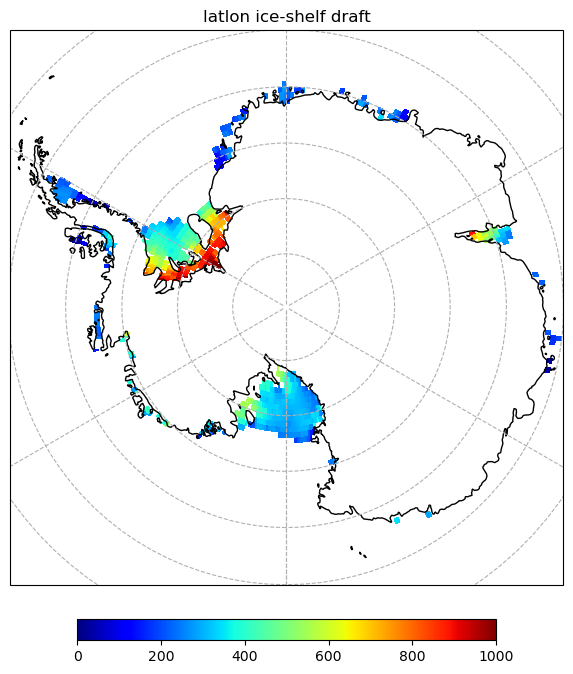

In [356]:
fig = plt.figure(figsize=(9,9))

# 1. Define the North Polar Stereographic projection
# Change central_longitude to rotate the map (e.g., -90 for North America up)
projection_n = ccrs.SouthPolarStereo(central_longitude=0)
ax = plt.axes(projection=projection_n)

# 2. Limit the map strictly from 65°N to 90°N
ax.set_extent([-180, 180, -90, -65], crs=ccrs.PlateCarree())

# 3. Force the map boundary to be a neat circle at 65°N
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T

# Add map features
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
#ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=False, linestyle='--')

vmin=0
vmax=1000
# 2. Set NaN values ('bad' data) to none (transparent)
cmap = plt.colormaps['jet'].copy()
cmap.set_bad(color='none')
#vmax=5000

tmp  = np.where(ice_shelf_draft_latlon == 0, np.nan, ice_shelf_draft_latlon)

im = ax.pcolormesh(ice_shelf_draft_latlon.longitude, ice_shelf_draft_latlon.latitude,
                   tmp,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap, 
                   vmin=vmin, 
                   vmax=vmax, 
                   edgecolors='none', # Change to 'white' if you want to see tile borders
                   antialiased=False)

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)

plt.title("latlon ice-shelf draft")
plt.show()

## seaflor depth beneath ice shelf

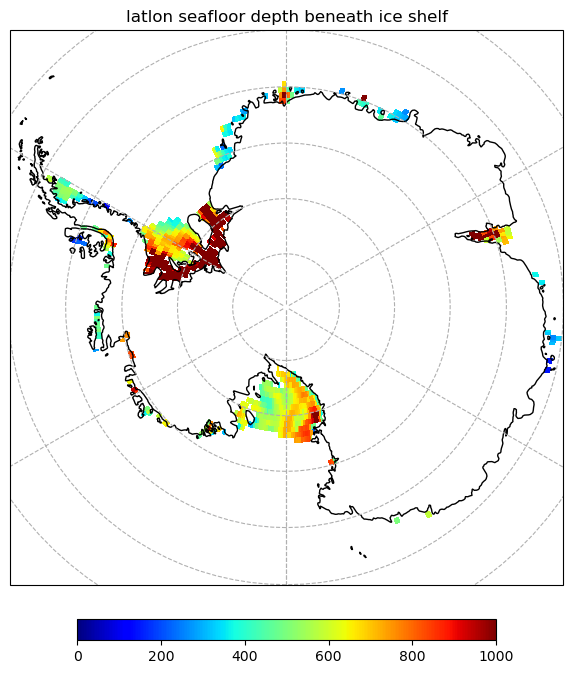

In [357]:
fig = plt.figure(figsize=(9,9))

# 1. Define the North Polar Stereographic projection
# Change central_longitude to rotate the map (e.g., -90 for North America up)
projection_n = ccrs.SouthPolarStereo(central_longitude=0)
ax = plt.axes(projection=projection_n)

# 2. Limit the map strictly from 65°N to 90°N
ax.set_extent([-180, 180, -90, -65], crs=ccrs.PlateCarree())

# 3. Force the map boundary to be a neat circle at 65°N
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T

# Add map features
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
#ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=False, linestyle='--')

vmin=0
vmax=1000
# 2. Set NaN values ('bad' data) to none (transparent)
cmap = plt.colormaps['jet'].copy()
cmap.set_bad(color='none')
#vmax=5000

tmp  = np.where(seafloor_depth_beneath_ice_shelf == 0, np.nan, seafloor_depth_beneath_ice_shelf)

im = ax.pcolormesh(ice_shelf_draft_latlon.longitude, ice_shelf_draft_latlon.latitude,
                   tmp,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap, 
                   vmin=vmin, 
                   vmax=vmax, 
                   edgecolors='none', # Change to 'white' if you want to see tile borders
                   antialiased=False)

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)

plt.title("latlon seafloor depth beneath ice shelf")
plt.show()

## new Depth

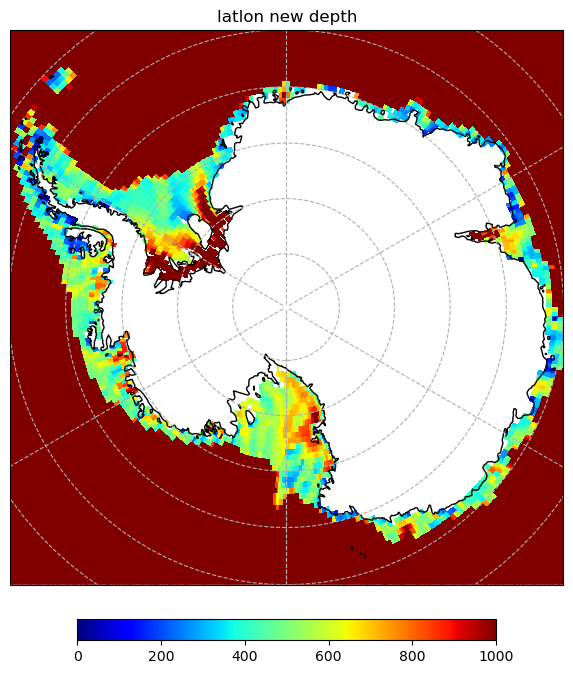

In [358]:
fig = plt.figure(figsize=(9,9))

# 1. Define the North Polar Stereographic projection
# Change central_longitude to rotate the map (e.g., -90 for North America up)
projection_n = ccrs.SouthPolarStereo(central_longitude=0)
ax = plt.axes(projection=projection_n)

# 2. Limit the map strictly from 65°N to 90°N
ax.set_extent([-180, 180, -90, -65], crs=ccrs.PlateCarree())

# 3. Force the map boundary to be a neat circle at 65°N
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T

# Add map features
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
#ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=False, linestyle='--')

vmin=0
vmax=1000
# 2. Set NaN values ('bad' data) to none (transparent)
cmap = plt.colormaps['jet'].copy()
cmap.set_bad(color='none')
#vmax=5000

tmp  = np.where(new_depth_latlon ==0, np.nan, new_depth_latlon)

im = ax.pcolormesh(ice_shelf_draft_latlon.longitude, ice_shelf_draft_latlon.latitude,
                   tmp,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap, 
                   vmin=vmin, 
                   vmax=vmax, 
                   edgecolors='none', # Change to 'white' if you want to see tile borders
                   antialiased=False)

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)

plt.title("latlon new depth")
plt.show()

# Bring it all together

In [ ]:

# assign proper name to Depth
new_depth_latlon.name = 'Depth'

In [398]:
# reconstruct to drop 'k'
hFacC_latlon = xr.DataArray(hFacC_latlon.values, dims=['Z','latitude','longitude'],
            coords={
                'latitude': mapping_factors.lats_1D,
                'longitude': mapping_factors.lons_1D
            })

hFacC_latlon.name = 'hFacC'

In [399]:
# change cavity mask to boolean
cavity_mask_latlon=cavity_mask_latlon.astype('bool')

# create a 3D mask C
maskC_latlon = hFacC_latlon.copy(deep=True)
maskC_latlon.values = np.where(hFacC_latlon == 0, False, True)
maskC_latlon.values = maskC_latlon.values.astype('bool')
maskC_latlon.name = 'maskC'

In [400]:
# reconstruct to drop 'k'
maskC_latlon = xr.DataArray(maskC_latlon.values, dims=['Z','latitude','longitude'],
            coords={
                'latitude': mapping_factors.lats_1D,
                'longitude': mapping_factors.lons_1D
            })

maskC_latlon.name = 'maskC'

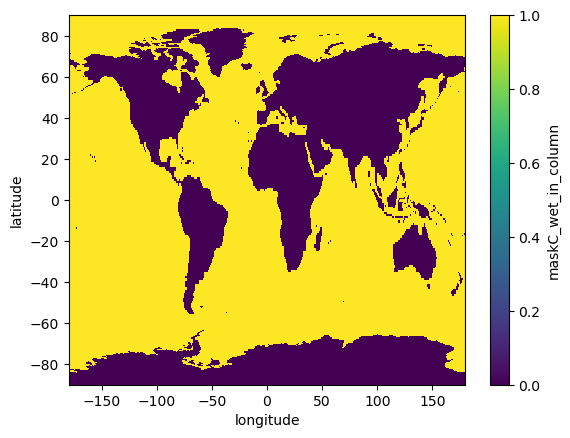

In [401]:
# maskC wet in column (2D)
maskC_wet_in_column_latlon = maskC_latlon[0].copy(deep=True);
maskC_wet_in_column_latlon.values = np.where(ocean_column_thickness_latlon > 0, True, False)
maskC_wet_in_column_latlon.name = 'maskC_wet_in_column'
maskC_wet_in_column_latlon.plot()

In [402]:
# copy the area values from latlon_area_and_radius
area_latlon = latlon_area_and_radius.target_grid_area.copy(deep=True)
area_latlon.name = 'area'
area_latlon=area_latlon.rename({'lat':'latitude'})
area_latlon=area_latlon.rename({'lon':'longitude'})

In [403]:
# vertical grid spacing from the native grid geometry file
tmp = native_ds.drF.copy(deep=True)
drF_latlon = tmp.drop_vars('k')
drF_latlon = xr.DataArray(drF_latlon.values, dims=['Z'])
drF_latlon.name = 'drF'

### Make the dataset

In [406]:
ecco_grid_ll = xr.merge([hFacC_latlon, new_depth_latlon, area_latlon, 
                         ocean_column_thickness_latlon, ice_shelf_draft_latlon, 
                         maskC_latlon, maskC_wet_in_column_latlon, cavity_mask_latlon, drF_latlon])
ecco_grid_ll.attrs = dict()

# assign coords
ecco_grid_ll = ecco_grid_ll.assign_coords({"latitude_bnds": (("latitude","nb"), latitude_bnds)})
ecco_grid_ll = ecco_grid_ll.assign_coords({"longitude_bnds": (("longitude","nb"), longitude_bnds)})
ecco_grid_ll = ecco_grid_ll.assign_coords({"Z": (("Z"), native_ds.Z.values)})
ecco_grid_ll = ecco_grid_ll.assign_coords({"Z_bnds": (("Z","nv"), depth_bnds)})

#ecco_grid_ll=ecco_grid_ll.drop_vars('k')
ecco_grid_ll

<xarray.Dataset> Size: 125MB
Dimensions:                 (latitude: 360, longitude: 720, Z: 50, nb: 2, nv: 2)
Coordinates:
  * latitude                (latitude) float64 3kB -89.75 -89.25 ... 89.25 89.75
  * longitude               (longitude) float64 6kB -179.8 -179.2 ... 179.8
    latitude_bnds           (latitude, nb) float64 6kB -90.0 -89.5 ... 89.5 90.0
    longitude_bnds          (longitude, nb) float64 12kB -180.0 -179.5 ... 180.0
  * Z                       (Z) float32 200B -5.0 -15.0 ... -5.906e+03
    Z_bnds                  (Z, nv) float64 800B 0.0 -10.0 ... -6.134e+03
Dimensions without coordinates: nb, nv
Data variables:
    hFacC                   (Z, latitude, longitude) float64 104MB 0.0 ... 0.0
    Depth                   (latitude, longitude) float64 2MB nan ... 4.072e+03
    area                    (latitude, longitude) float64 2MB ...
    ocean_column_thickness  (latitude, longitude) float64 2MB 0.0 ... 4.072e+03
    ice_shelf_draft         (latitude, longitude) float64 2MB 0.0 0.0 ... 0.0
    maskC                   (Z, latitude, longitude) bool 13MB False ... False
    maskC_wet_in_column     (latitude, longitude) bool 259kB False ... True
    cavity_mask             (latitude, longitude) bool 259kB False ... False
    drF                     (Z) float32 200B 10.0 10.0 10.0 ... 433.5 456.5

## Final sanity check plots

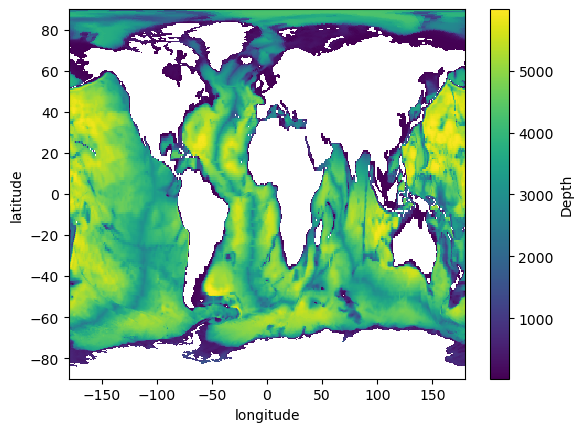

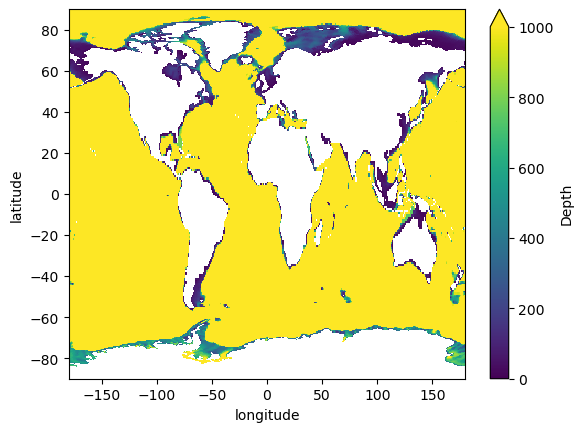

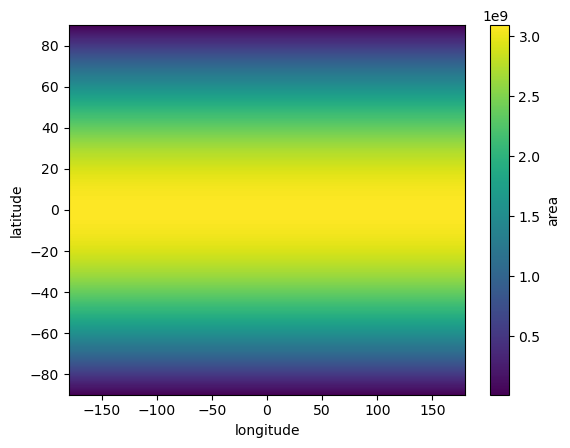

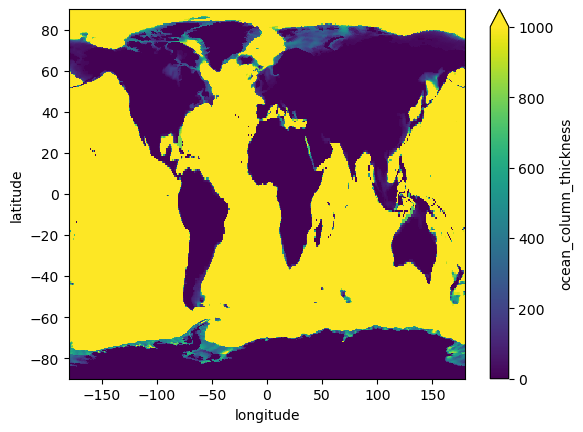

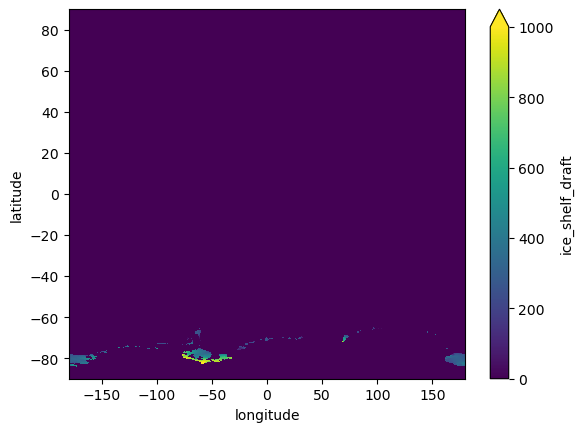

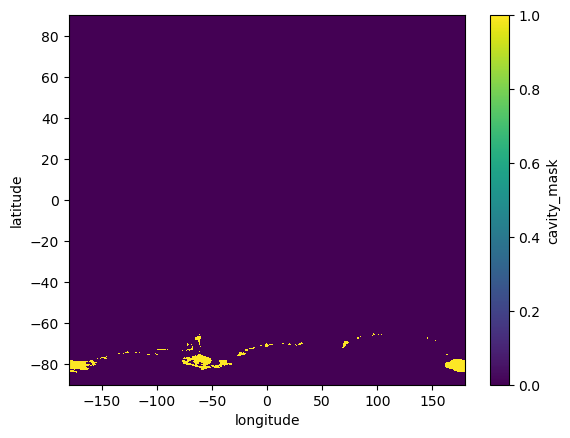

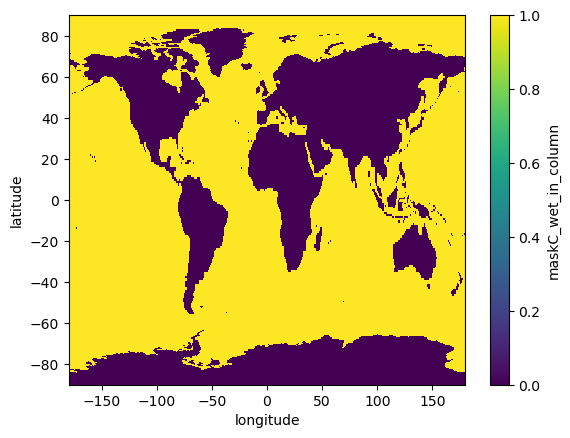

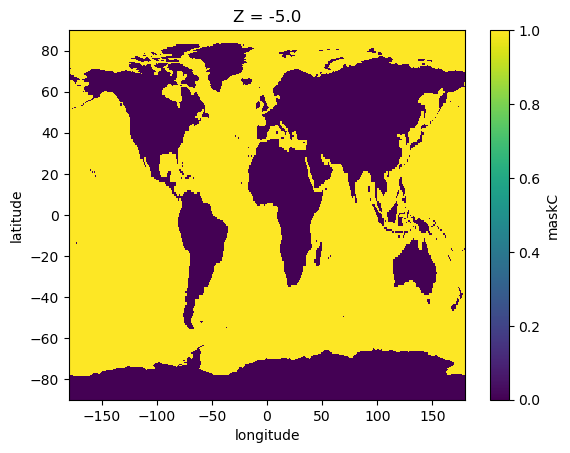

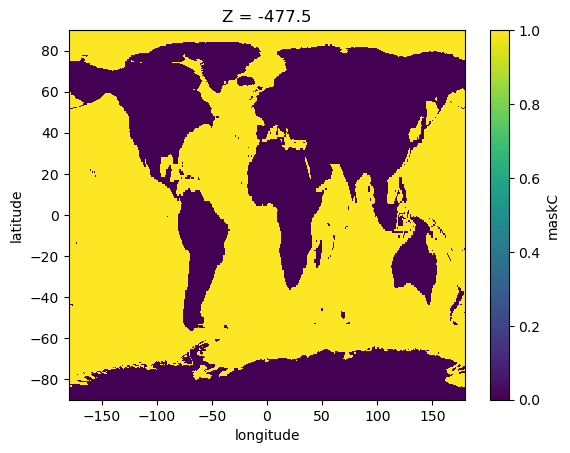

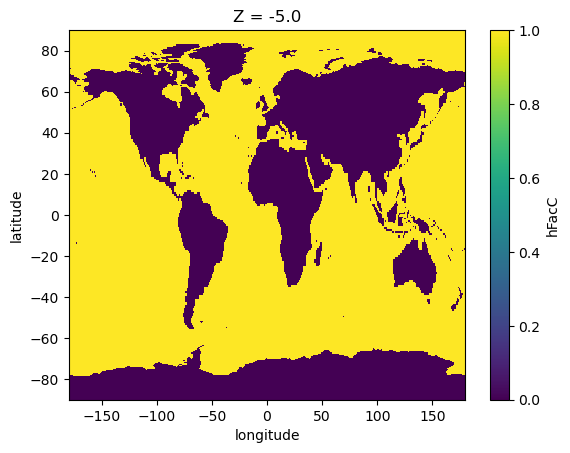

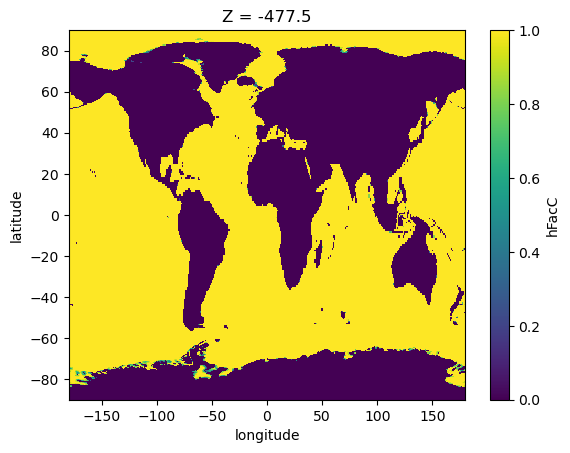

In [405]:
ecco_grid_ll.Depth.plot()
plt.figure()
ecco_grid_ll.Depth.plot(vmin=0,vmax=1000)
plt.figure()

ecco_grid_ll.area.plot()
plt.figure()
ecco_grid_ll.ocean_column_thickness.plot(vmin=0,vmax=1000)


plt.figure()
ecco_grid_ll.ice_shelf_draft.plot(vmin=0,vmax=1000)


plt.figure()
ecco_grid_ll.cavity_mask.plot()


plt.figure()
ecco_grid_ll.maskC_wet_in_column.plot()

plt.figure()
ecco_grid_ll.maskC[0].plot()

plt.figure()
ecco_grid_ll.maskC[22].plot()

plt.figure()
ecco_grid_ll.hFacC[0].plot()

plt.figure()
ecco_grid_ll.hFacC[22].plot()

## Step 8: Create Output Dataset

In [408]:
# Add processing history
history_entry = f"{datetime.datetime.now().isoformat()}: Created latlon grid geometry using EDP mapping factors"

if 'history' in ecco_grid_ll.attrs:
    ecco_grid_ll.attrs['history'] = history_entry + "; " + ecco_grid_ll.attrs['history']
else:
    ecco_grid_ll.attrs['history'] = history_entry

print("\n✓ Output dataset created")
print(f"  Variables: {len(ecco_grid_ll.data_vars)}")
print(f"  Dimensions: {dict(ecco_grid_ll.dims)}")
print(f"  Grid label: {ecco_grid_ll.attrs.get('grid_label', 'N/A')}")
print(f"\n  Data variables:")

for var in sorted(ecco_grid_ll.data_vars):
    print(f"    {var:20s} {str(ecco_grid_ll[var].dims):40s} {ecco_grid_ll[var].shape}")


✓ Output dataset created
  Variables: 9
  Dimensions: {'latitude': 360, 'longitude': 720, 'Z': 50, 'nb': 2, 'nv': 2}
  Grid label: N/A

  Data variables:
    Depth                ('latitude', 'longitude')                (360, 720)
    area                 ('latitude', 'longitude')                (360, 720)
    cavity_mask          ('latitude', 'longitude')                (360, 720)
    drF                  ('Z',)                                   (50,)
    hFacC                ('Z', 'latitude', 'longitude')           (50, 360, 720)
    ice_shelf_draft      ('latitude', 'longitude')                (360, 720)
    maskC                ('Z', 'latitude', 'longitude')           (50, 360, 720)
    maskC_wet_in_column  ('latitude', 'longitude')                (360, 720)
    ocean_column_thickness ('latitude', 'longitude')                (360, 720)


/var/folders/1_/d2mlmphx1y73x199m02l7_qc0000gq/T/ipykernel_68980/1394927695.py:11: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Dimensions: {dict(ecco_grid_ll.dims)}")


## Step 9: Write Output File

In [390]:
output_file

'/Users/ifenty/tmp/pre_GRID_GEOMETRY_ECCO_V4r6_latlon_0p50deg.nc'

In [409]:
log.info(f"Writing output to: {output_file}")

# Set up encoding for compression
comp_settings = cfg.get('netcdf4_compression_encodings', 
                       {'zlib': True, 'complevel': 5, 'shuffle': True})

encoding = {}
for var_name in ecco_grid_ll.data_vars:
    encoding[var_name] = comp_settings.copy()

ecco_grid_ll.to_netcdf(output_file, encoding=encoding)

print("\n" + "="*60)
print("SUCCESS! Latlon grid geometry file created.")
print(f"Output: {output_file}")
print("="*60)

# Close datasets
native_ds.close()
ecco_grid_ll.close()

INFO       2026-05-26 07:44:36,540 Writing output to: /Users/ifenty/tmp/pre_GRID_GEOMETRY_ECCO_V4r6_latlon_0p50deg.nc



SUCCESS! Latlon grid geometry file created.
Output: /Users/ifenty/tmp/pre_GRID_GEOMETRY_ECCO_V4r6_latlon_0p50deg.nc


## Step 10: Verification

Quick verification of the output file.

In [410]:
# Reload and verify
verify_ds = xr.open_dataset(output_file)

print("\n✓ Output file verification")
print(f"  File: {output_file}")
print(f"  Variables: {len(verify_ds.data_vars)}")
print(f"  Dimensions: {dict(verify_ds.dims)}")
print(f"\n  Sample variable checks:")

for var in ['area', 'ocean_column_thickness', 'hFacC', 'ice_shelf_draft']:
    if var in verify_ds:
        v = verify_ds[var]
        print(f"\n    {var}:")
        print(f"      Shape: {v.shape}")
        print(f"      Range: [{np.nanmin(v.values):.2f}, {np.nanmax(v.values):.2f}]")
        print(f"      NaN %: {np.isnan(v.values).sum() / v.size * 100:.1f}%")
        if 'long_name' in v.attrs:
            print(f"      Long name: {v.attrs['long_name']}")

verify_ds.close()
print("\n✓ Verification complete")


✓ Output file verification
  File: /Users/ifenty/tmp/pre_GRID_GEOMETRY_ECCO_V4r6_latlon_0p50deg.nc
  Variables: 9
  Dimensions: {'latitude': 360, 'longitude': 720, 'Z': 50, 'nb': 2, 'nv': 2}

  Sample variable checks:

    area:
      Shape: (360, 720)
      Range: [13487323.48, 3091047233.90]
      NaN %: 0.0%

    ocean_column_thickness:
      Shape: (360, 720)
      Range: [0.00, 5997.99]
      NaN %: 0.0%

    hFacC:
      Shape: (50, 360, 720)
      Range: [0.00, 1.00]
      NaN %: 0.0%

    ice_shelf_draft:
      Shape: (360, 720)


/var/folders/1_/d2mlmphx1y73x199m02l7_qc0000gq/T/ipykernel_68980/1388692950.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Dimensions: {dict(verify_ds.dims)}")


      Range: [0.00, 1099.18]
      NaN %: 0.0%

✓ Verification complete


In [394]:
output_file

'/Users/ifenty/tmp/pre_GRID_GEOMETRY_ECCO_V4r6_latlon_0p50deg.nc'

## Optional: Add ECCO Metadata

To add full ECCO metadata to the grid geometry file, use the `edp_add_metadata` tool:

```bash
edp_add_metadata -g latlon -s --input /Users/ifenty/tmp/pre_GRID_GEOMETRY_ECCO_V4r6_latlon_0p50deg.nc --output GRID_GEOMETRY_ECCO_V4r6_latlon_0p50deg.nc --metadata ~/git_repo_others/ECCO-v4-Configurations/ECCOv4\ Release\ 6/metadata --config ~/git_repo_others/ECCO-Dataset-Production/configs/config_V4r6.yaml --log DEBUG
```

This will add:
- Variable metadata (long_name, units, standard_name)
- Coordinate metadata
- Global attributes (DOI, GCMD keywords, etc.)
- PO.DAAC-specific metadata
- Grid geometry-specific summary description